# Split GSM8K into easy/hard for the e3 curriculum

This notebook turns a per-problem difficulty eval into the training parquets used by Track C (clean), Track D (mixed) and Track E (trivia-only):

- `train_easy_clean.parquet`, `train_hard_clean.parquet`
- `train_easy_mixed.parquet`, `train_hard_mixed.parquet`
- `train_easy_trivia.parquet`, `train_hard_trivia.parquet`

It also lets you **spot-check** sample correctly / incorrectly answered questions alongside the model's generated answers before deciding on the split threshold.

**How to use:**
1. Run a difficulty eval on the GSM8K train split (e.g. on the base model or on a trained checkpoint).
2. Update `EVAL_TAG` in the config cell below to match your eval's `--output-tag`.
3. Run the notebook cells in order. First spot-check correct vs incorrect answers, then choose a split fraction based on the accuracy distribution.

## 1. Configuration

In [7]:
import os
import sys
import subprocess
import random

import pandas as pd
import datasets

# Repo root so we can reuse the gsm8k_padded helpers.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

VOLUME = "e3-generation-vol"
REMOTE_DIR = "e3_gsm8k"                      # /data/e3_gsm8k on the Volume

# CHANGE THIS to match the --output-tag of your eval run.
# Example base-model eval: "train_strict_l512"
# Example trained checkpoint eval: "track_a_final_1024"
EVAL_TAG = "track_a_final_1024"

PER_PROBLEM_CSV = f"per_problem_gsm8k_qwen_{EVAL_TAG}.csv"
OUTPUTS_PARQUET = f"gsm8k_qwen_{EVAL_TAG}_outputs.parquet"
METRICS_JSON = f"metrics_gsm8k_qwen_{EVAL_TAG}.json"

# Local working dir for downloaded artifacts + generated parquets.
LOCAL_DIR = os.path.join(REPO_ROOT, "scripts", "e3-grpo-gsm8k", "data_e3_gsm8k")
os.makedirs(LOCAL_DIR, exist_ok=True)

SEED = 42
print(f"REPO_ROOT={REPO_ROOT}\nLOCAL_DIR={LOCAL_DIR}\nEVAL_TAG={EVAL_TAG}")

REPO_ROOT=/home/chung/coding_projects/cs224r-project-e3
LOCAL_DIR=/home/chung/coding_projects/cs224r-project-e3/scripts/e3-grpo-gsm8k/data_e3_gsm8k
EVAL_TAG=track_a_final_1024


## 2. Download eval artifacts from the Modal Volume

In [8]:
def modal_get(remote_name: str):
    """Download a file from the Volume into LOCAL_DIR (overwrites)."""
    remote_path = f"{REMOTE_DIR}/{remote_name}"
    local_path = os.path.join(LOCAL_DIR, remote_name)
    if os.path.exists(local_path):
        os.remove(local_path)
    cmd = ["modal", "volume", "get", VOLUME, remote_path, local_path]
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)
    return local_path

per_problem_path = modal_get(PER_PROBLEM_CSV)
# The outputs parquet (with base-model responses) is only needed for spot-checking.
try:
    outputs_path = modal_get(OUTPUTS_PARQUET)
except subprocess.CalledProcessError:
    outputs_path = None
    print("[warn] outputs parquet not found; spot-check of model answers will be skipped")

+ modal volume get e3-generation-vol e3_gsm8k/per_problem_gsm8k_qwen_track_a_final_1024.csv /home/chung/coding_projects/cs224r-project-e3/scripts/e3-grpo-gsm8k/data_e3_gsm8k/per_problem_gsm8k_qwen_track_a_final_1024.csv
⠋ Downloading file(s) to local...
⠸ Downloading file(s) to local...0 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ .
⠦ Downloading file(s) to local...0 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ .
⠏ Downloading file(s) to local...0 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ .
⠹ Downloading file(s) to local...0 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ .
⠴ Downloading file(s) to local...1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ .
e3_gsm8k/per_problem_gsm8k_qwen_track_a_final_1024.csv ━━━ 0.0% • 0.… • ? • -:-…
⠇ Downloading file(s) to local...mkB            
e3_gsm8k/per_problem_gsm8k_qwen_track_a_final_1024.csv ━━━ 0.0% • 0.… • ? • -:-…
⠹ Downloading file(s) to local...mkB            
e3_gsm8k/per_problem_gsm8k_qwen_track_a_final_1024.csv ━━━ 0.0% • 0.… • ? • -:-…
⠴ Downloading file(s) to 

## 3. Inspect accuracy distribution & spot-check correct vs incorrect answers

First, look at the overall accuracy stats. Then inspect some correctly and incorrectly answered questions to understand what kinds of problems the model struggles with.

After that, we split into easy/hard using **answer position** as a proxy for reasoning difficulty:
- **HARD**: all incorrectly answered questions (the model couldn't solve them at all)
- **EASY**: correctly answered questions where `####answer` appears at or before the 75th percentile character position (the model got it right quickly, without much reasoning)
- **HARD**: correctly answered questions where `####answer` appears after the 75th percentile (the model had to reason extensively before getting it right)

This yields an approximate 70/30 easy/hard split that respects both correctness and reasoning effort.

In [9]:
# 3a. Load results and show distribution
per_problem = pd.read_csv(per_problem_path)
print(f"loaded {len(per_problem)} problems")
print(per_problem["accuracy"].describe())

correct_idx = set(per_problem[per_problem["accuracy"] == 1.0]["problem_idx"].astype(int))
wrong_idx = set(per_problem[per_problem["accuracy"] == 0.0]["problem_idx"].astype(int))
partial_idx = set(per_problem[(per_problem["accuracy"] > 0.0) & (per_problem["accuracy"] < 1.0)]["problem_idx"].astype(int))
print(f"\ncorrect={len(correct_idx)}  wrong={len(wrong_idx)}  partial={len(partial_idx)}")

# Load gsm8k dataset (needed for questions)
ds = datasets.load_dataset("openai/gsm8k", "main")
train_raw = ds["train"]
test_raw = ds["test"]
print(f"gsm8k train={len(train_raw)}  test={len(test_raw)}")
assert len(train_raw) == len(per_problem), (
    "per-problem rows must align 1:1 with the gsm8k train split order"
)

# Load outputs parquet for model responses
outputs_path_local = os.path.join(LOCAL_DIR, OUTPUTS_PARQUET)
if os.path.exists(outputs_path_local):
    outputs_df = pd.read_parquet(outputs_path_local)
    print(f"loaded outputs: {len(outputs_df)} rows")
else:
    outputs_df = None
    print("[warn] outputs parquet not found locally; responses will not be shown")

from examples.data_preprocess.gsm8k_padded import extract_solution
import re

N_SHOW = 3

def first_response(idx):
    if outputs_df is None or idx >= len(outputs_df):
        return "<no response>"
    resps = outputs_df.iloc[idx]["responses"]
    return resps[0] if len(resps) else "<empty>"

def show_sample(name, indices, n=3):
    print("=" * 100)
    print(f"{name.upper()} SAMPLES (showing {n})")
    print("=" * 100)
    sample = sorted(random.Random(SEED).sample(sorted(indices), min(n, len(indices))))
    for idx in sample:
        ex = train_raw[int(idx)]
        gt = extract_solution(ex["answer"])
        print(f"\n[idx={idx}]")
        print("Q:", ex["question"][:500])
        print("GT:", gt)
        print("Model:", str(first_response(int(idx)))[:1800])

# 3b. Spot-check correct vs incorrect
show_sample("correctly answered", correct_idx, N_SHOW)
show_sample("incorrectly answered", wrong_idx, N_SHOW)

# 3c. Compute character positions of ####answer for correct questions
positions = []
for idx in sorted(correct_idx):
    resp = str(first_response(int(idx)))
    match = re.search(r"####\s*(\-?[0-9\.\,]+)", resp)
    if match:
        positions.append(match.start())
    else:
        positions.append(len(resp))

pos_series = pd.Series(positions)
position_threshold = int(pos_series.quantile(0.75))

# Build a lookup: problem_idx -> position (only for correct answers)
correct_positions = {}
for idx, pos in zip(sorted(correct_idx), positions):
    correct_positions[idx] = pos

# Split:
# - EASY: correct answers where ####answer appears at or before 75th percentile position
# - HARD: everything else (wrong + partial + late correct)
easy_idx = set()
hard_idx = set(wrong_idx) | set(partial_idx)

for idx in correct_idx:
    pos = correct_positions.get(idx, float('inf'))
    if pos <= position_threshold:
        easy_idx.add(idx)
    else:
        hard_idx.add(idx)

print(f"\n>>> EASY/HARD SPLIT (position-based, 75th pctile)")
print(f"threshold = {position_threshold} chars")
print(f"easy={len(easy_idx)}  hard={len(hard_idx)}")
print(f"  (of {len(correct_idx)} correct: {len(easy_idx)} early, {len(hard_idx) - len(wrong_idx) - len(partial_idx)} late)")
print(f"  (wrong={len(wrong_idx)}  partial={len(partial_idx)}")

loaded 7473 problems
count    7473.000000
mean        0.927874
std         0.258714
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: accuracy, dtype: float64

correct=6934  wrong=539  partial=0
gsm8k train=7473  test=1319
loaded outputs: 7473 rows
CORRECTLY ANSWERED SAMPLES (showing 3)

[idx=221]
Q: Mira jogs every morning. She jogs 5 miles per hour. If she jogs for 2 hours every morning, how many miles can she jog for five days?
GT: 50
Model: <think>
Okay, let me see. Mira jogs every morning, and she jogs 5 miles per hour. She jogs for 2 hours each morning. I need to figure out how many miles she can jog in five days. 

First, maybe I should figure out how many miles she jogs in one day. Since she jogs 5 miles per hour for 2 hours, I can multiply those two numbers together. So 5 miles/hour times 2 hours would be 10 miles per day. 

Then, if she does this every day for five days, I need to multiply the daily miles by the num

## 3.5. Histogram: where does the correct answer appear?

For correctly answered questions, we measure at which character position the model first writes `####answer`. If the answer appears early, the model didn't have to "think" much. If it appears late, the model did more reasoning. This gives an alternative view of difficulty beyond simple right/wrong.

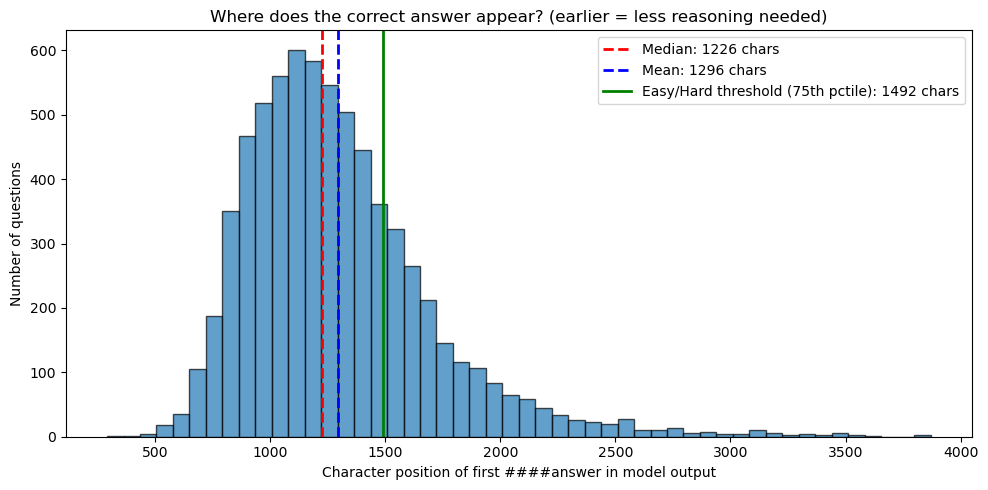


SAMPLE QUESTIONS AT DIFFERENT ANSWER-POSITION PERCENTILES

--- 10th percentile (pos ~863, actual 863) ---
Q: Phoebe eats 1 serving and gives her dog 1 serving of peanut butter for a bedtime snack. Each jar of peanut butter has 15 servings.  How many jars will she need to make sure she and her dog have enough to last for 30 days?...

--- 25th percentile (pos ~1014, actual 1014) ---
Q: Mom went shopping at the market. She left with €55. She bought 2 packs of bananas for €4 each, pears for €2, asparagus for €6 and finally a chicken for €11. How much money does Mom have left?...

--- 50th percentile (pos ~1226, actual 1226) ---
Q: Arnel had ten boxes of pencils with the same number of pencils in each box.  He kept ten pencils and shared the remaining pencils equally with his five friends. If his friends got eight pencils each, how many pencils are in each box?...

--- 75th percentile (pos ~1492, actual 1492) ---
Q: Lance has 70 cents, Margaret has three-fourths of a dollar, Guy has two qu

In [10]:
# Plot histogram: character position of first ####answer in correctly answered questions
# positions, pos_series, and position_threshold were computed in the previous cell.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(positions, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(pos_series.median(), color='red', linestyle='--', linewidth=2,
            label=f"Median: {pos_series.median():.0f} chars")
plt.axvline(pos_series.mean(), color='blue', linestyle='--', linewidth=2,
            label=f"Mean: {pos_series.mean():.0f} chars")
plt.axvline(position_threshold, color='green', linestyle='-', linewidth=2,
            label=f"Easy/Hard threshold (75th pctile): {position_threshold} chars")
plt.xlabel("Character position of first ####answer in model output")
plt.ylabel("Number of questions")
plt.title("Where does the correct answer appear? (earlier = less reasoning needed)")
plt.legend()
plt.tight_layout()
plt.show()

# Show sample questions at different percentiles to build intuition
print("\n" + "=" * 80)
print("SAMPLE QUESTIONS AT DIFFERENT ANSWER-POSITION PERCENTILES")
print("=" * 80)
for p in [10, 25, 50, 75, 90]:
    target_pos = int(pos_series.quantile(p / 100))
    closest_idx_in_list = min(range(len(positions)), key=lambda i: abs(positions[i] - target_pos))
    sample_idx = sorted(correct_idx)[closest_idx_in_list]
    actual_pos = positions[closest_idx_in_list]
    q = train_raw[int(sample_idx)]["question"]
    print(f"\n--- {p}th percentile (pos ~{target_pos}, actual {actual_pos}) ---")
    print(f"Q: {q[:250]}...")

## 4. Build the parquets (reusing gsm8k_padded helpers)

In [11]:
from examples.data_preprocess.gsm8k_padded import (
    build_row,
    extract_solution,
    TRIVIA_FACTS,
)

# train_raw and test_raw already loaded in the previous cell
rng = random.Random(SEED)

def build_clean_rows(indices):
    rows = []
    for new_i, orig_i in enumerate(sorted(indices)):
        ex = train_raw[int(orig_i)]
        q, a = ex["question"], ex["answer"]
        gt = extract_solution(a)
        rows.append(build_row(q, gt, "train", new_i, a, q))
    return rows

def build_mixed_rows(indices):
    # Clean originals first, then one trivia-padded clone of each (Track-D style).
    clean = build_clean_rows(indices)
    M = len(clean)
    padded = []
    for k, orig_i in enumerate(sorted(indices)):
        ex = train_raw[int(orig_i)]
        q, a = ex["question"], ex["answer"]
        gt = extract_solution(a)
        fact = rng.choice(TRIVIA_FACTS)
        padded_q = f"{fact} {q}"
        padded.append(build_row(padded_q, gt, "train", M + k, a, padded_q))
    return clean + padded

def build_trivia_only_rows(indices):
    # Track-E style: ONLY trivia-padded clones, no clean originals.
    padded = []
    for k, orig_i in enumerate(sorted(indices)):
        ex = train_raw[int(orig_i)]
        q, a = ex["question"], ex["answer"]
        gt = extract_solution(a)
        fact = rng.choice(TRIVIA_FACTS)
        padded_q = f"{fact} {q}"
        padded.append(build_row(padded_q, gt, "train", k, a, padded_q))
    return padded

def write_parquet(rows, name):
    path = os.path.join(LOCAL_DIR, name)
    datasets.Dataset.from_list(rows).to_parquet(path)
    print(f"wrote {len(rows):>6} rows -> {name}")
    return path

write_parquet(build_clean_rows(easy_idx), "train_easy_clean.parquet")
write_parquet(build_clean_rows(hard_idx), "train_hard_clean.parquet")
write_parquet(build_mixed_rows(easy_idx), "train_easy_mixed.parquet")
write_parquet(build_mixed_rows(hard_idx), "train_hard_mixed.parquet")
# Track E (trivia-only): appended after C/D so their parquets stay identical.
write_parquet(build_trivia_only_rows(easy_idx), "train_easy_trivia.parquet")
write_parquet(build_trivia_only_rows(hard_idx), "train_hard_trivia.parquet")

# Clean test split (shared validation set for all tracks).
test_rows = []
for i, ex in enumerate(test_raw):
    gt = extract_solution(ex["answer"])
    test_rows.append(build_row(ex["question"], gt, "test", i, ex["answer"], ex["question"]))
write_parquet(test_rows, "test.parquet")

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 114.34ba/s]


wrote   5202 rows -> train_easy_clean.parquet


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 221.48ba/s]


wrote   2271 rows -> train_hard_clean.parquet


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 86.98ba/s]


...

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 259.61ba/s]


wrote   2271 rows -> train_hard_trivia.parquet


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 484.11ba/s]

wrote   1319 rows -> test.parquet


'/home/chung/coding_projects/cs224r-project-e3/scripts/e3-grpo-gsm8k/data_e3_gsm8k/test.parquet'

## 5. Spot-check: easy vs hard questions + model answers

Eyeball a few examples from each bucket to confirm the split is sensible before training.

In [12]:
N_SHOW = 5

def show_bucket(name, indices):
    print("=" * 100)
    print(f"{name.upper()} SAMPLES")
    print("=" * 100)
    sample = sorted(random.Random(SEED).sample(sorted(indices), min(N_SHOW, len(indices))))
    for idx in sample:
        ex = train_raw[int(idx)]
        acc = per_problem.loc[per_problem["problem_idx"] == idx, "accuracy"].values
        acc = float(acc[0]) if len(acc) else float("nan")
        print(f"\n[idx={idx}  acc={acc:.2f}]")
        print("Q:", ex["question"][:400])
        print("GT:", extract_solution(ex["answer"]))
        print("Model:", str(first_response(int(idx)))[:600])

show_bucket("easy", easy_idx)
show_bucket("hard", hard_idx)

EASY SAMPLES

[idx=293  acc=1.00]
Q: For every 1 minute that Carlotta sings on stage during the final opera performance, she spends an additional 3 minutes practicing and 5 minutes throwing temper tantrums. If her final stage performance is 6 minutes long, what is the total combined amount of time, in minutes, that she spends practicing, throwing tantrums, and singing in the final stage performance?
GT: 54
Model: <think>
Okay, let's see. Carlotta sings on stage for 6 minutes in her final opera performance. For every minute she sings, she spends 3 minutes practicing and 5 minutes throwing tantrums. I need to find the total time she spends on all these activities.

First, the singing time is given as 6 minutes. For each minute of singing, she practices for 3 minutes and throws tantrums for 5 minutes. So, I guess I need to calculate the practice time and tantrum time based on the singing time.

Let me break it down. If she sings for 6 minutes, then the practice time would be 6 minutes mul

In [13]:
# Pre-upload safety check: compare the parquets we just built against any copies
# already on the Modal Volume. This is READ-ONLY -- it never writes, overwrites,
# or deletes anything on the Volume.
import hashlib
import tempfile

EXPECTED_FILES = [
    "train_easy_clean.parquet",
    "train_hard_clean.parquet",
    "train_easy_mixed.parquet",
    "train_hard_mixed.parquet",
    "train_easy_trivia.parquet",
    "train_hard_trivia.parquet",
    "test.parquet",
]


def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def list_remote_files():
    """Return the set of filenames present in REMOTE_DIR on the Volume."""
    cmd = ["modal", "volume", "ls", VOLUME, REMOTE_DIR]
    try:
        out = subprocess.run(cmd, check=True, capture_output=True, text=True).stdout
    except subprocess.CalledProcessError as e:
        print(f"[warn] could not list remote dir ({e}); treating remote as empty")
        return set()
    names = set()
    for line in out.splitlines():
        # Match any expected filename appearing anywhere on the line (handles
        # both plain `ls` output and the bordered table format).
        for fname in EXPECTED_FILES:
            if fname in line:
                names.add(fname)
    return names


def fetch_remote(remote_name, dest_dir):
    """Download a remote file into dest_dir; return local path or None on failure."""
    remote_path = f"{REMOTE_DIR}/{remote_name}"
    local_path = os.path.join(dest_dir, remote_name)
    cmd = ["modal", "volume", "get", VOLUME, remote_path, local_path]
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print(f"[warn] failed to download {remote_name} for comparison: {e}")
        return None
    return local_path


def compare_parquets(local_path, remote_path):
    """Return (status, detail) comparing two parquet files at byte + dataframe level."""
    local_size = os.path.getsize(local_path)
    remote_size = os.path.getsize(remote_path)

    local_hash = sha256_of(local_path)
    remote_hash = sha256_of(remote_path)
    byte_identical = (local_size == remote_size) and (local_hash == remote_hash)

    # DataFrame-level comparison (catches identical data with different encoding,
    # and confirms byte-identical files really are equal).
    try:
        df_local = pd.read_parquet(local_path)
        df_remote = pd.read_parquet(remote_path)
        df_equal = df_local.equals(df_remote)
        df_detail = f"rows local={len(df_local)} remote={len(df_remote)}"
    except Exception as e:  # noqa: BLE001 - report, don't crash the check
        df_equal = None
        df_detail = f"dataframe compare failed: {e}"

    if byte_identical and df_equal:
        return "IDENTICAL", f"sha256 match; {df_detail}"
    if byte_identical and df_equal is None:
        return "IDENTICAL?", f"bytes match but {df_detail}"
    if (not byte_identical) and df_equal:
        return "DIFFERENT", f"same data, different encoding ({df_detail})"
    return "DIFFERENT", (
        f"local_size={local_size} remote_size={remote_size}; "
        f"byte_identical={byte_identical}; df_equal={df_equal}; {df_detail}"
    )


remote_files = list_remote_files()
print(f"remote files found in {VOLUME}:/{REMOTE_DIR}: {sorted(remote_files) or '(none)'}\n")

results = {}
with tempfile.TemporaryDirectory() as tmp_dir:
    for name in EXPECTED_FILES:
        local_path = os.path.join(LOCAL_DIR, name)
        if not os.path.exists(local_path):
            results[name] = ("LOCAL_MISSING", "build it in Step 4 first")
            continue
        if name not in remote_files:
            results[name] = ("MISSING", "safe to upload (not on Volume yet)")
            continue
        remote_path = fetch_remote(name, tmp_dir)
        if remote_path is None:
            results[name] = ("ERROR", "could not download remote copy")
            continue
        results[name] = compare_parquets(local_path, remote_path)
    # tmp_dir (with all downloaded remote copies) is cleaned up on context exit.

print("=" * 80)
print(f"{'FILE':<28} {'STATUS':<14} DETAIL")
print("-" * 80)
for name in EXPECTED_FILES:
    status, detail = results[name]
    print(f"{name:<28} {status:<14} {detail}")
print("=" * 80)

conflicts = [n for n, (s, _) in results.items() if s.startswith("DIFFERENT") or s == "ERROR"]
if conflicts:
    print(f"\nConflicts detected in {len(conflicts)} file(s) — review before uploading: {conflicts}")
else:
    print("\nNo conflicts found — safe to proceed to Step 6 upload")

remote files found in e3-generation-vol:/e3_gsm8k: ['test.parquet', 'train_easy_clean.parquet', 'train_easy_mixed.parquet', 'train_hard_clean.parquet', 'train_hard_mixed.parquet']

FILE                         STATUS         DETAIL
--------------------------------------------------------------------------------
train_easy_clean.parquet     IDENTICAL      sha256 match; rows local=5202 remote=5202
train_hard_clean.parquet     IDENTICAL      sha256 match; rows local=2271 remote=2271
train_easy_mixed.parquet     IDENTICAL      sha256 match; rows local=10404 remote=10404
train_hard_mixed.parquet     IDENTICAL      sha256 match; rows local=4542 remote=4542
train_easy_trivia.parquet    MISSING        safe to upload (not on Volume yet)
train_hard_trivia.parquet    MISSING        safe to upload (not on Volume yet)
test.parquet                 IDENTICAL      sha256 match; rows local=1319 remote=1319

No conflicts found — safe to proceed to Step 6 upload


## 6. Next step

Once the split looks good, upload the parquets to the Volume:
```bash
modal run scripts/data_upload_e3_gsm8k.py --local-dir scripts/e3-grpo-gsm8k/data_e3_gsm8k
```